In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/climate.csv")

df.head()

Matplotlib is building the font cache; this may take a moment.


,Date,City,State,Temperature_Max (°C),Temperature_Min (°C),Temperature_Avg (°C),Humidity (%),Rainfall (mm),Wind_Speed (km/h),AQI,AQI_Category,Pressure (hPa),Cloud_Cover (%)
0,2024-01-01,Mumbai,Maharashtra,32.5,18.0,25.2,77.6,0.0,3.3,259,Poor,1020.3,62.1
1,2024-01-01,Delhi,Delhi,25.4,10.7,18.1,84.1,0.0,9.0,130,Moderate,1008.4,46.0
2,2024-01-01,Bengaluru,Karnataka,37.2,30.8,34.0,49.0,3.7,6.6,54,Satisfactory,1008.0,61.3
3,2024-01-01,Chennai,Tamil Nadu,37.2,30.4,33.8,34.2,9.5,9.0,176,Moderate,993.4,70.0
4,2024-01-01,Kolkata,West Bengal,27.4,17.5,22.5,32.2,9.1,9.2,97,Satisfactory,1008.2,56.9


In [2]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (7310, 13)

Columns:
['Date', 'City', 'State', 'Temperature_Max (°C)', 'Temperature_Min (°C)', 'Temperature_Avg (°C)', 'Humidity (%)', 'Rainfall (mm)', 'Wind_Speed (km/h)', 'AQI', 'AQI_Category', 'Pressure (hPa)', 'Cloud_Cover (%)']

Data Types:
Date                        str
City                        str
State                       str
Temperature_Max (°C)    float64
Temperature_Min (°C)    float64
Temperature_Avg (°C)    float64
Humidity (%)            float64
Rainfall (mm)           float64
Wind_Speed (km/h)       float64
AQI                       int64
AQI_Category                str
Pressure (hPa)          float64
Cloud_Cover (%)         float64
dtype: object

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 7310 entries, 0 to 7309
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  7310 non-null   str    
 1   City                  7310 non-null   str    
 2

,Temperature_Max (°C),Temperature_Min (°C),Temperature_Avg (°C),Humidity (%),Rainfall (mm),Wind_Speed (km/h),AQI,Pressure (hPa),Cloud_Cover (%)
count,7310.000000,7310.000000,7310.000000,7310.000000,7310.000000,7310.000000,7310.000000,7310.000000,7310.000000
mean,34.952161,25.006402,29.980192,62.653516,8.231300,13.522763,193.759508,1007.358577,52.630055
std,5.781372,6.476264,5.966698,18.680171,17.758208,6.562729,89.182569,10.109978,27.327729
min,25.000000,10.100000,17.600000,30.000000,0.000000,2.000000,40.000000,990.000000,5.000000
25%,30.000000,19.900000,25.000000,46.400000,0.000000,7.900000,116.000000,998.700000,28.925000
50%,34.900000,25.000000,30.000000,62.700000,0.000000,13.500000,194.000000,1007.300000,52.700000
75%,40.000000,30.000000,35.000000,78.700000,6.300000,19.100000,270.000000,1016.200000,76.200000
max,45.000000,39.800000,42.300000,95.000000,79.900000,25.000000,349.000000,1025.000000,100.000000



Missing Values:
Date                    0
City                    0
State                   0
Temperature_Max (°C)    0
Temperature_Min (°C)    0
Temperature_Avg (°C)    0
Humidity (%)            0
Rainfall (mm)           0
Wind_Speed (km/h)       0
AQI                     0
AQI_Category            0
Pressure (hPa)          0
Cloud_Cover (%)         0
dtype: int64

Duplicate Rows: 0


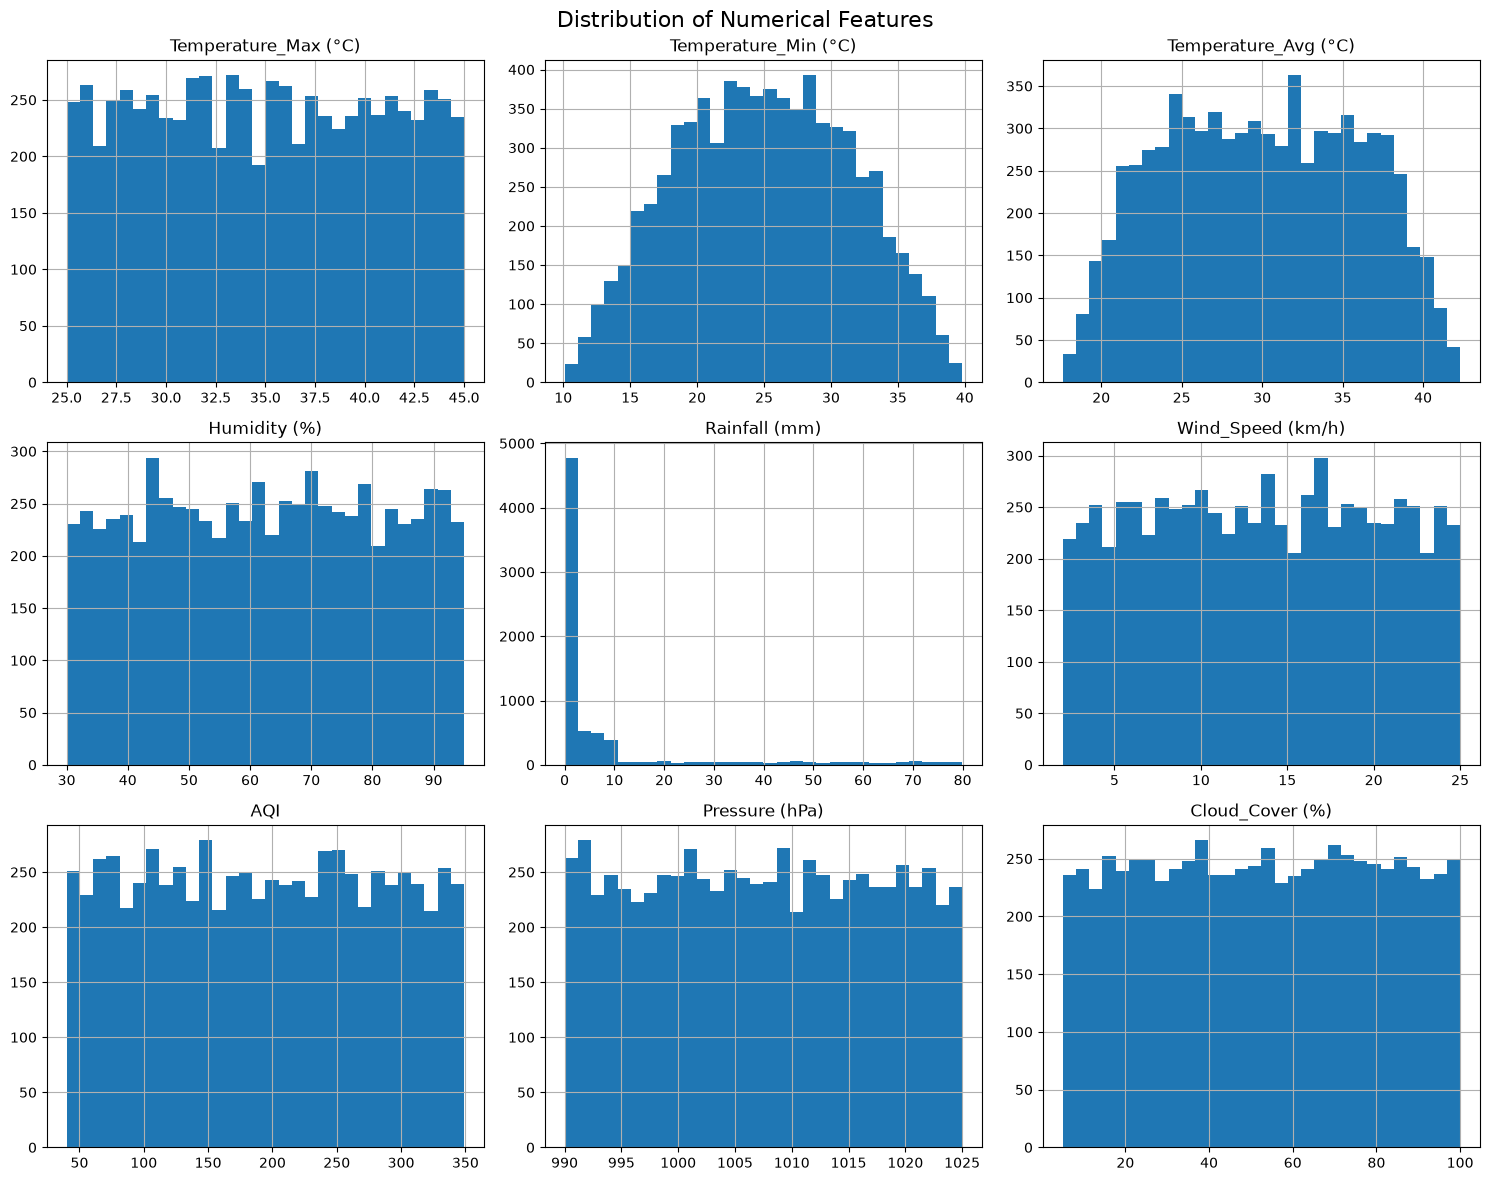

In [3]:
numerical_cols = df.select_dtypes(include=np.number).columns

df[numerical_cols].hist(
    figsize=(15, 12),
    bins=30
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

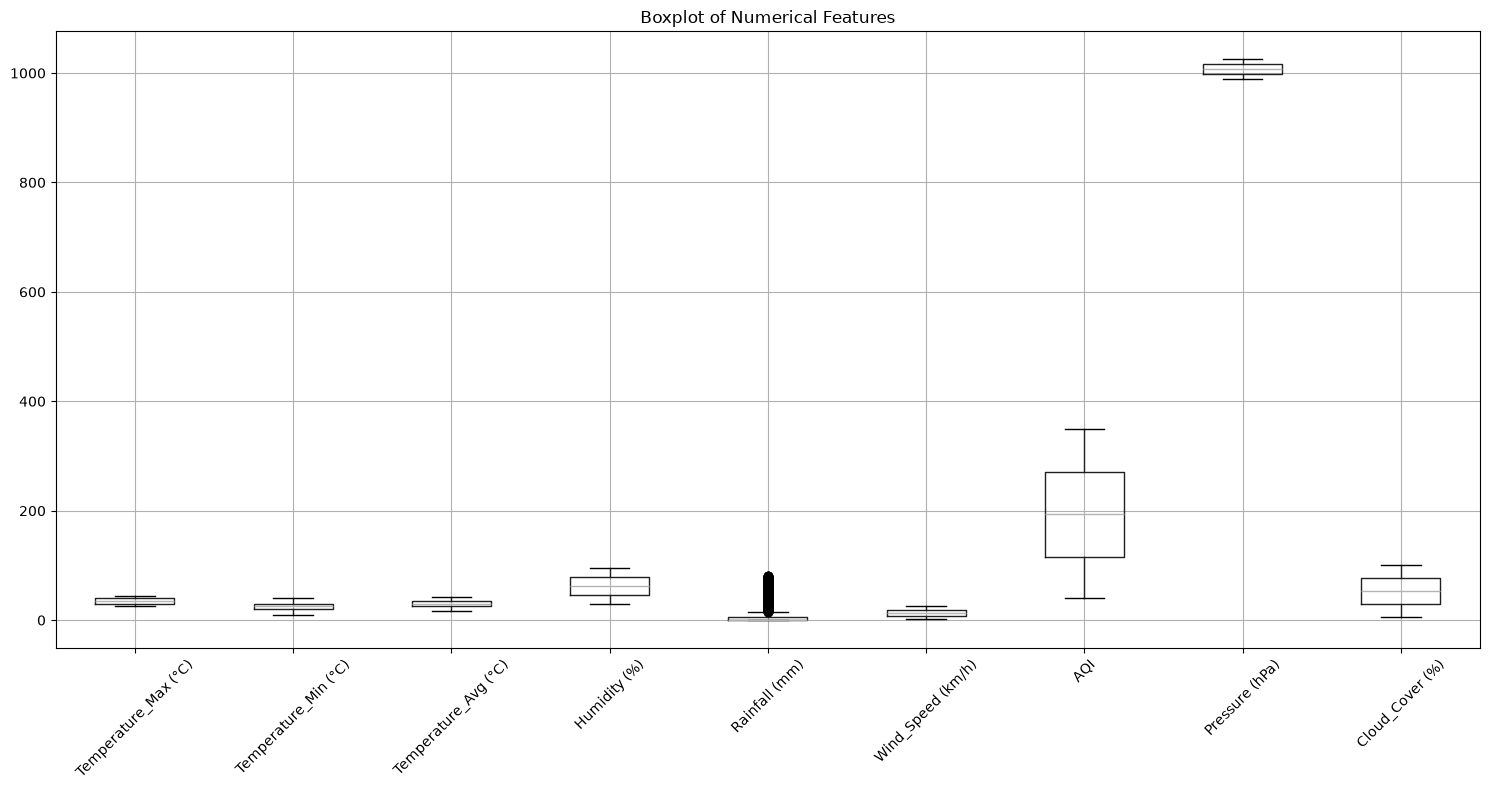

In [4]:
plt.figure(figsize=(15, 8))

df[numerical_cols].boxplot()

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

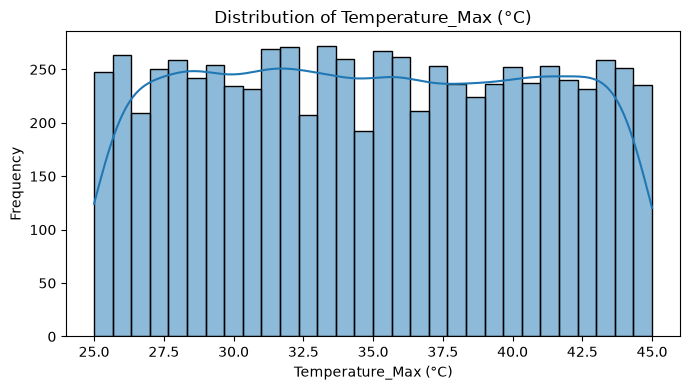

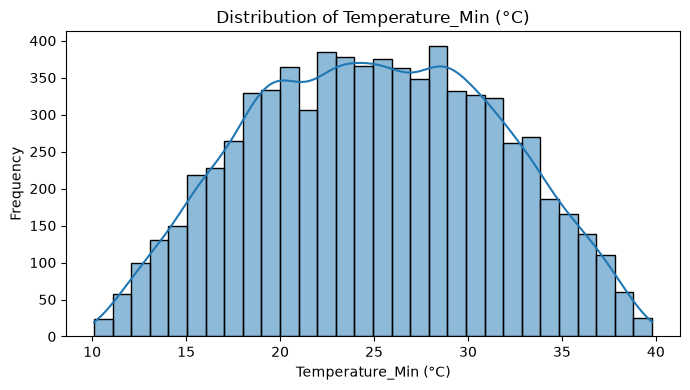

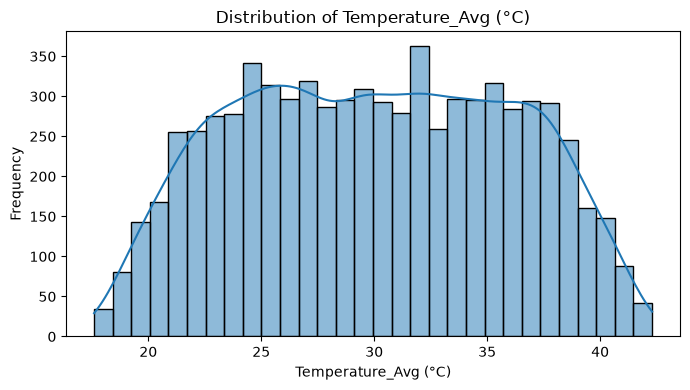

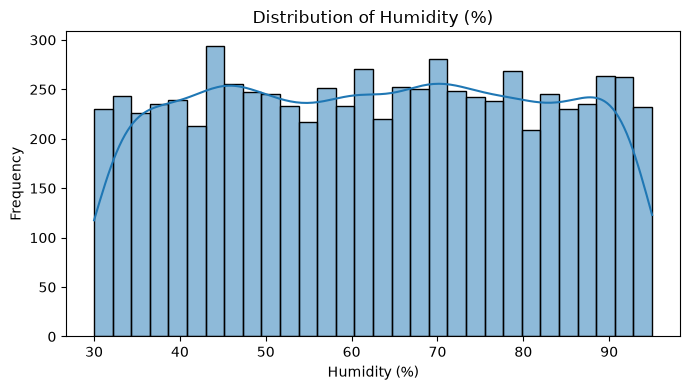

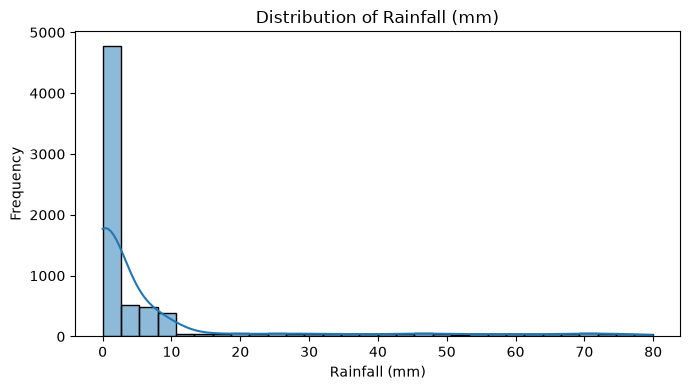

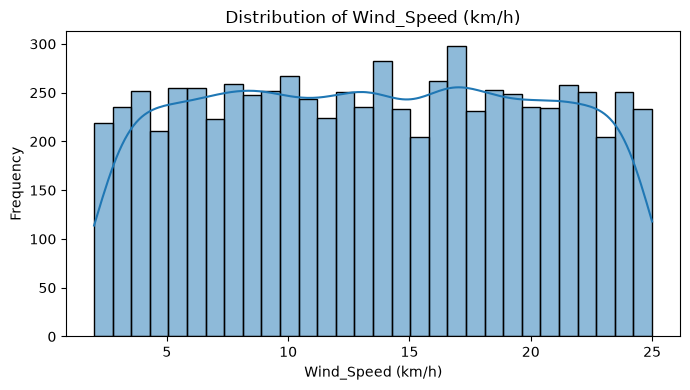

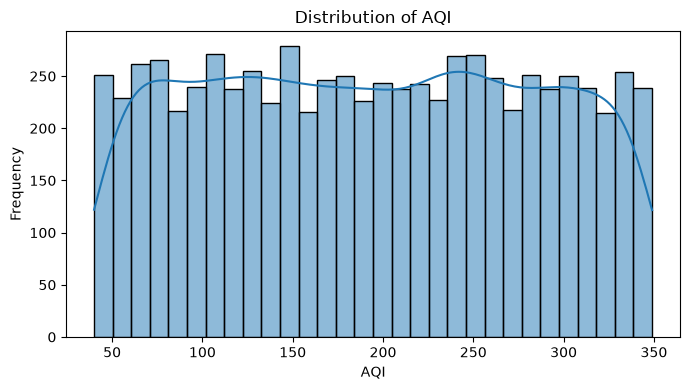

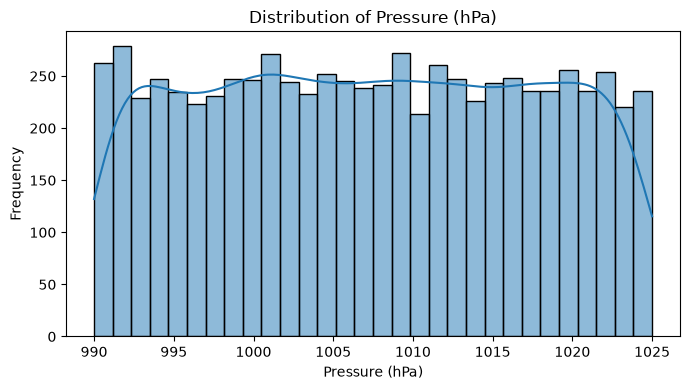

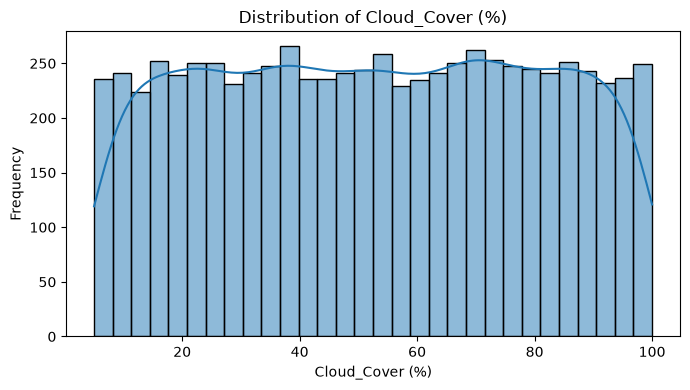

In [5]:
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [6]:
categorical_cols = ["City", "State", "AQI_Category"]

for col in categorical_cols:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts())


City
Unique values: 10
City
Mumbai       731
Delhi        731
Bengaluru    731
Chennai      731
Kolkata      731
Hyderabad    731
Ahmedabad    731
Jaipur       731
Lucknow      731
Bhopal       731
Name: count, dtype: int64

State
Unique values: 10
State
Maharashtra       731
Delhi             731
Karnataka         731
Tamil Nadu        731
West Bengal       731
Telangana         731
Gujarat           731
Rajasthan         731
Uttar Pradesh     731
Madhya Pradesh    731
Name: count, dtype: int64

AQI_Category
Unique values: 5
AQI_Category
Moderate        2385
Poor            2344
Satisfactory    1194
Very Poor       1136
Good             251
Name: count, dtype: int64


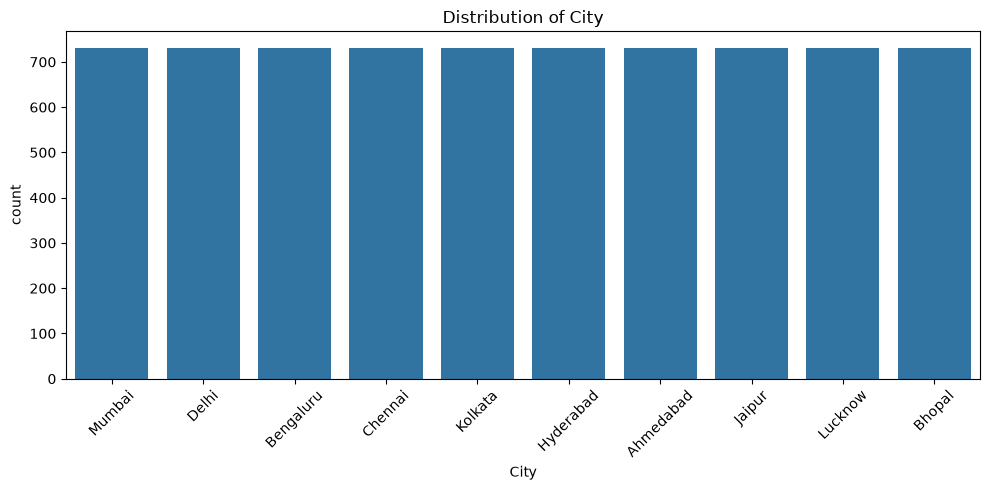

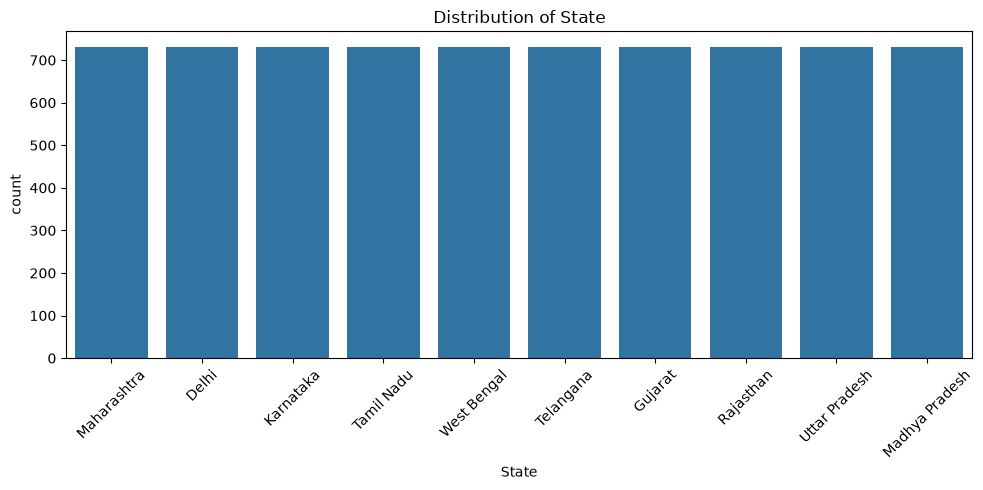

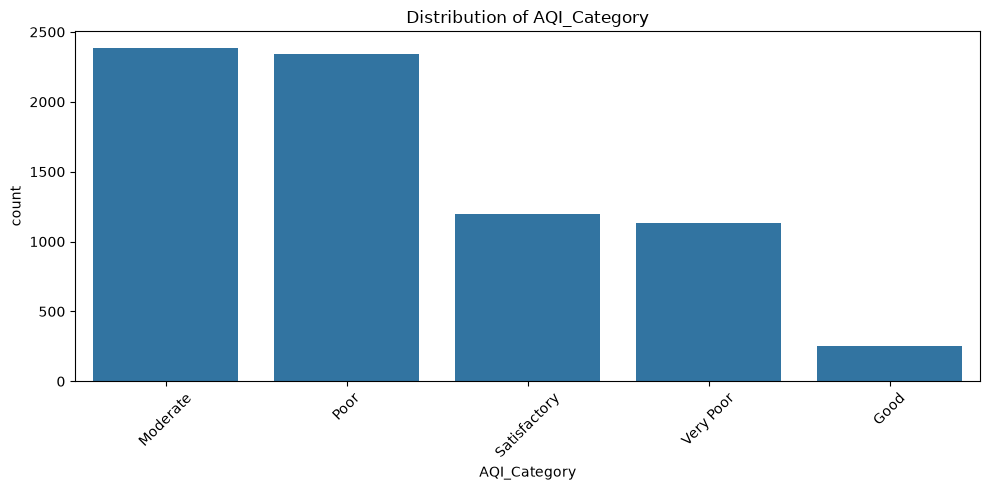

In [7]:
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )
    
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [8]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

datetime64[us]
Start Date: 2024-01-01 00:00:00
End Date: 2025-12-31 00:00:00


In [9]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

print("Years:", df["Year"].unique())
print("Months:", df["Month"].unique())

Years: [2024 2025]
Months: [ 1  2  3  4  5  6  7  8  9 10 11 12]


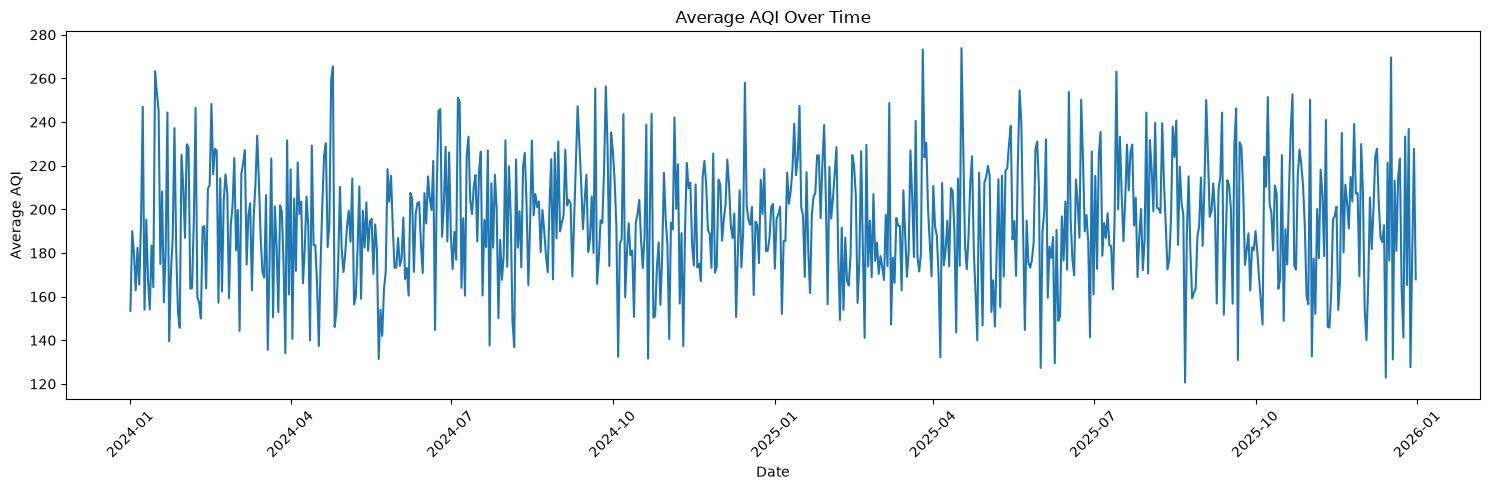

In [10]:
daily_aqi = df.groupby("Date")["AQI"].mean()

plt.figure(figsize=(15, 5))
plt.plot(daily_aqi.index, daily_aqi.values)

plt.title("Average AQI Over Time")
plt.xlabel("Date")
plt.ylabel("Average AQI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

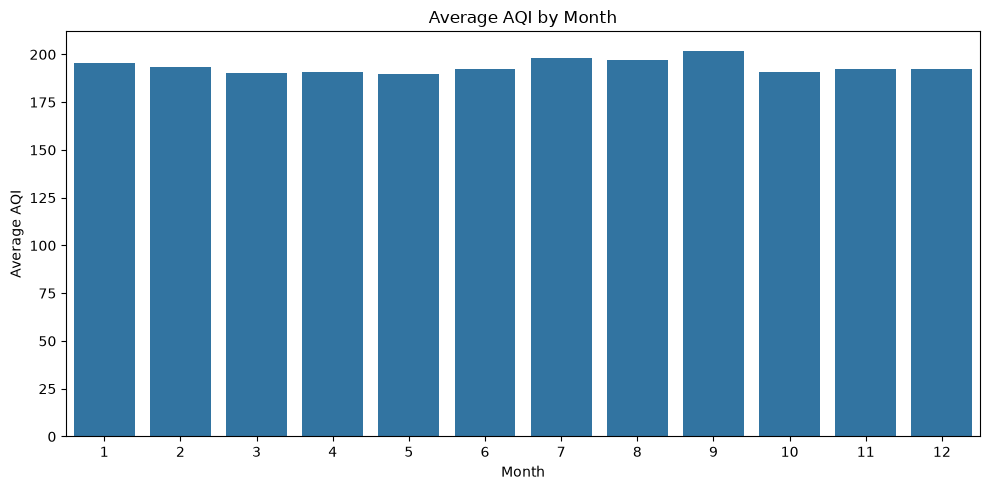

In [11]:
monthly_aqi = df.groupby("Month")["AQI"].mean()

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly_aqi.index, y=monthly_aqi.values)

plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.tight_layout()
plt.show()

## Target Variable Proposal

The proposed target variable for climate-risk prediction is **AQI (Air Quality Index)**.

AQI is selected as the target because it is a numerical measure that represents the level of air pollution and associated environmental risk. The dataset contains several weather-related features such as temperature, humidity, rainfall, wind speed, pressure, and cloud cover that can be analyzed as potential predictors of AQI.

Therefore, AQI can be treated as the primary target variable for the prediction model developed in the next stage.

# EDA Findings Summary

- The dataset contains **7,310 observations and 13 variables**.
- The dataset contains **9 numerical variables and 4 text/categorical variables**.
- No missing values were found in any column.
- No duplicate rows were identified.
- Numerical feature distributions were analyzed using histograms, distribution plots, and boxplots.
- Categorical variables including City, State, and AQI Category were analyzed to understand their distributions.
- Date-based analysis was performed to investigate temporal and monthly patterns in AQI and temperature.
- Bivariate analysis was used to examine relationships between weather variables and AQI.
- A correlation matrix was created to identify relationships among numerical variables.
- **AQI was proposed as the target variable** for the climate-risk prediction model because it provides a numerical measure of air-quality risk.
- Overall, the EDA provides an understanding of the dataset and identifies potential weather-related predictors that can be used in the next stages of data cleaning, feature engineering, and model development.